<a href="https://colab.research.google.com/github/denis-hwk/pos-tech_fiap_9dtat/blob/desafios/Pos_Tech_Tech_Challenge_2_Series_Temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ta
!pip install StatsForecast

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=1670bc0063f7e708c677227290bd7b04f8b7b7e66ca0eea4a255f0b4c7ec6e57
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 10.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


# Configurações
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")


def get_ibovespa_data(start_date='2023-01-01', end_date='2025-08-01'):
    """
    Coleta dados históricos do Ibovespa
    """
    if end_date is None:
        end_date = datetime.now().strftime('%Y-%m-%d')

    print(f"\nDados do Ibovespa de {start_date} até {end_date}")

    # Ticker do Ibovespa
    ibov = yf.download('^BVSP', start=start_date, end=end_date)

    print(f"✅ {len(ibov)} dias de dados coletados")
    print(f"📈 Período: {ibov.index[0].strftime('%Y-%m-%d')} a {ibov.index[-1].strftime('%Y-%m-%d')}")

    return ibov

# Coletando os dados
df = get_ibovespa_data(start_date='2023-01-01', end_date='2025-08-01')

# Informações básicas
print(f"\nInformações dos dados:")
print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
print(f"Valores faltantes: {df.isnull().sum().sum()}")



[*********************100%***********************]  1 of 1 completed


Dados do Ibovespa de 2023-01-01 até 2025-08-01
✅ 644 dias de dados coletados
📈 Período: 2023-01-02 a 2025-07-31

Informações dos dados:
Shape: (644, 5)
Colunas: [('Close', '^BVSP'), ('High', '^BVSP'), ('Low', '^BVSP'), ('Open', '^BVSP'), ('Volume', '^BVSP')]
Valores faltantes: 0


In [5]:
dataset = pd.DataFrame()
dataset['Close'] = df['Close']
dataset['High'] = df['High']
dataset['Low'] = df['Low']
dataset['Open'] = df['Open']
dataset['Volume'] = df['Volume']

dataset.head()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-02,106376.0,109734.0,105981.0,109734.0,8130500
2023-01-03,104166.0,106684.0,103852.0,106377.0,14466700
2023-01-04,105334.0,105627.0,103915.0,104167.0,14451200
2023-01-05,107518.0,107743.0,105333.0,105336.0,15512000
2023-01-06,108836.0,109433.0,107642.0,107642.0,12626600


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 644 entries, 2023-01-02 to 2025-07-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   644 non-null    float64
 1   High    644 non-null    float64
 2   Low     644 non-null    float64
 3   Open    644 non-null    float64
 4   Volume  644 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 30.2 KB


## Análise Exploratória de Dados

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [8]:
df_fechamento = dataset.copy()
df_fechamento.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
df_fechamento.head()

,Close
Date,
2023-01-02,106376.0
2023-01-03,104166.0
2023-01-04,105334.0
2023-01-05,107518.0
2023-01-06,108836.0


###Gráficos de Sazonalidade Decomposta

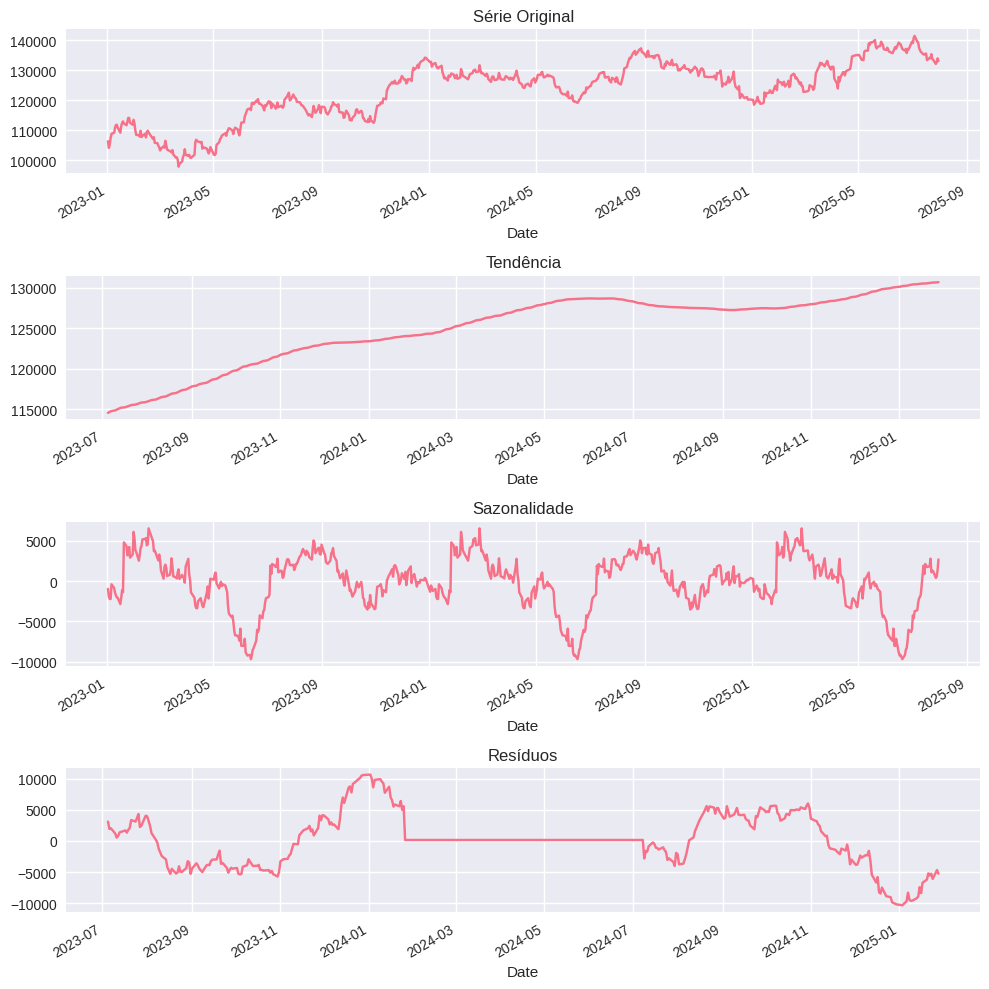

In [1076]:
eda_series = seasonal_decompose(df_fechamento, period = 252)

fig, axes = plt.subplots(4, 1, figsize=(10, 10))
eda_series.observed.plot(ax=axes[0], title='Série Original')
eda_series.trend.plot(ax=axes[1], title='Tendência')
eda_series.seasonal.plot(ax=axes[2], title='Sazonalidade')
eda_series.resid.plot(ax=axes[3], title='Resíduos')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Série Original'}, xlabel='Date'>

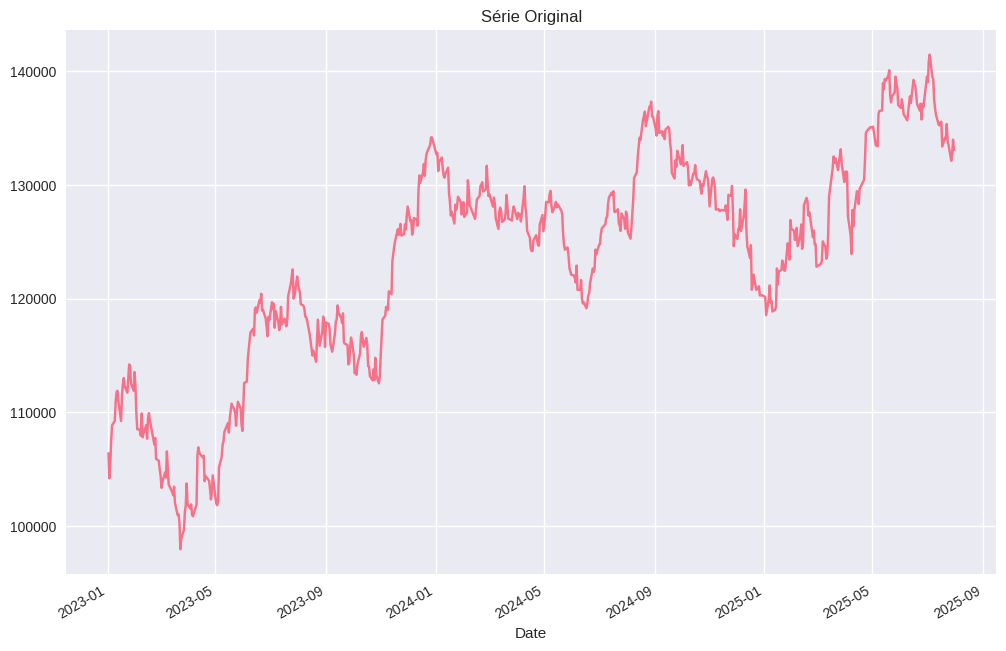

In [1078]:
eda_series.observed.plot(title='Série Original')

###Gráficos de Auto-correlação e Auto-correlação Parcial

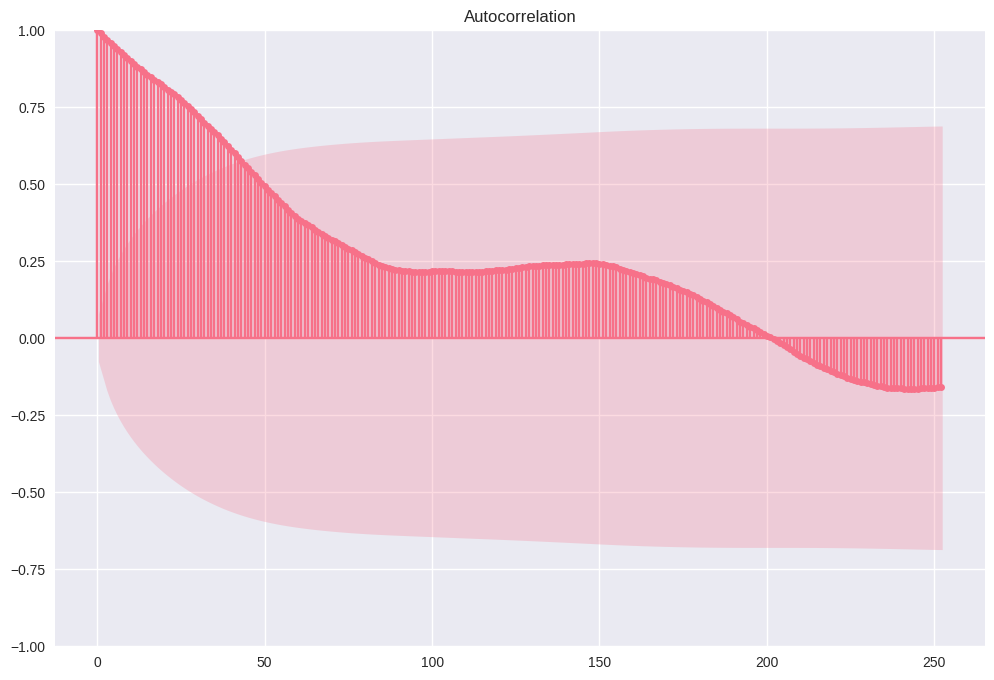

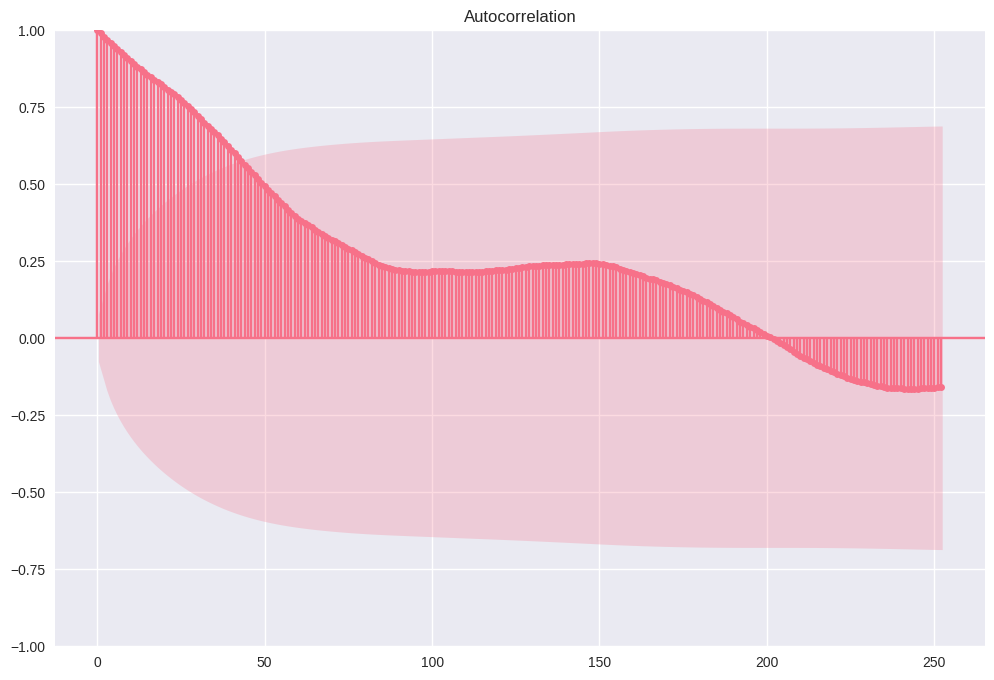

In [377]:
plot_acf(df_fechamento['Close'], lags= 252)

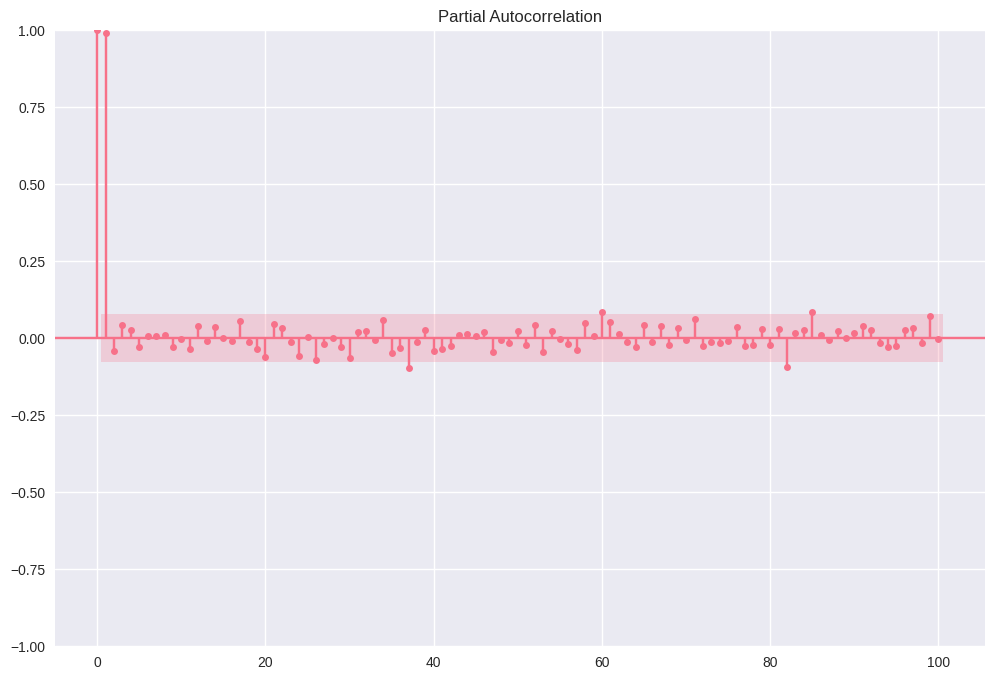

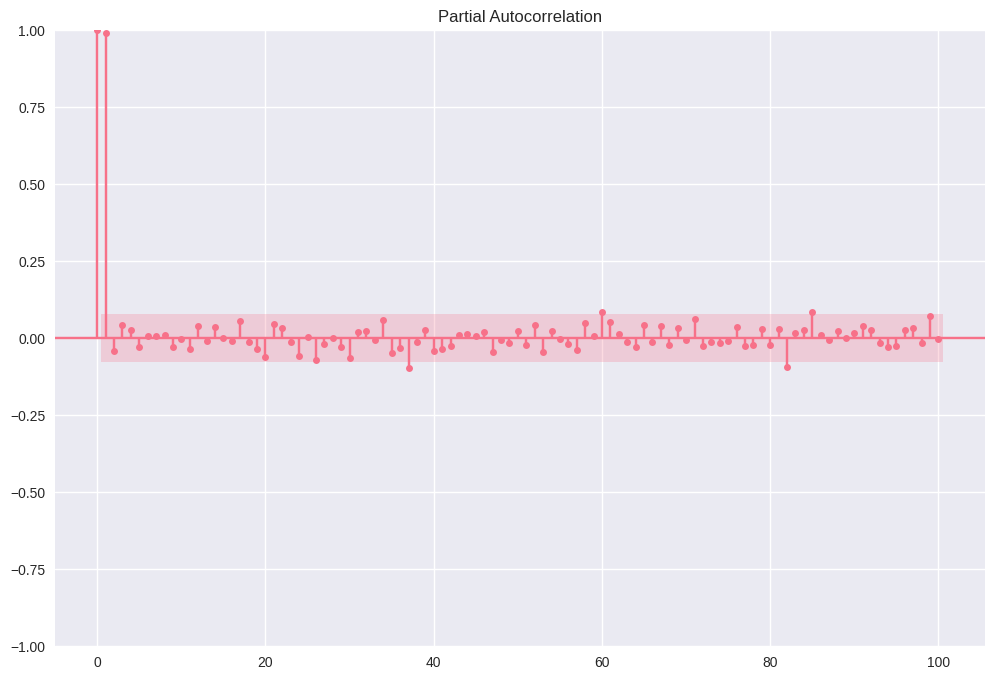

In [61]:
plot_pacf(df_fechamento['Close'], lags= 100)

###Teste ADFuller

In [17]:
resultado_adf = adfuller(df_fechamento)
print('Resultado do Teste AD Fuller')
print(f'Teste Estatístico: {resultado_adf[0]}')
print(f'P-value: {resultado_adf[1]}')
print('Valores críticos:')
for key, value in resultado_adf[4].items():
  print(f'\t{key}: {value}')

Resultado do Teste AD Fuller
Teste Estatístico: -1.8760826586333252
P-value: 0.34339486421434184
Valores críticos:
	1%: -3.440560883168159
	5%: -2.8660454146233434
	10%: -2.569169329058723


A partir dos resultados do teste ADF, não rejeitamos $H_0$.

Portanto, inferimos que a série não é estacionária.

Além do resultado do teste, podemos verificar nos gráficos de sazonalidade decomposta da série temporal que existe forte influência da tendência nos fechamentos diários.

### Separação dos grupos de treino e teste

In [172]:
df_sf = df_fechamento.copy()
df_sf['unique_id'] = 'Ibovespa'
df_sf = df_sf.reset_index()
df_sf.rename(columns = {'Date': 'ds', 'Close': 'y'}, inplace=True)

df_sf.head()

,ds,y,unique_id
0,2023-01-02,106376.0,Ibovespa
1,2023-01-03,104166.0,Ibovespa
2,2023-01-04,105334.0,Ibovespa
3,2023-01-05,107518.0,Ibovespa
4,2023-01-06,108836.0,Ibovespa


In [173]:
treino = df_sf.loc[df_sf['ds'] < '2025-07-01']
teste = df_sf.loc[df_sf['ds'] >= '2025-07-01']
print(f'Tamanho da base de treino: {len(treino)}')
print(f'Tamanho da base de teste: {len(teste)}')

Tamanho da base de treino: 621
Tamanho da base de teste: 23


## Modelos de Séries Temporais

In [804]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, SeasonalWindowAverage, AutoARIMA, MSTL, AutoETS
from statsforecast.utils import ConformalIntervals
from statsforecast.arima import arima_string

### Baseline (Naive)

In [174]:
model_naive = [Naive()]
naive = StatsForecast(models = model_naive, freq='b', n_jobs=-1)

In [175]:
naive.fit(treino)
result_baseline = naive.predict(h=23)

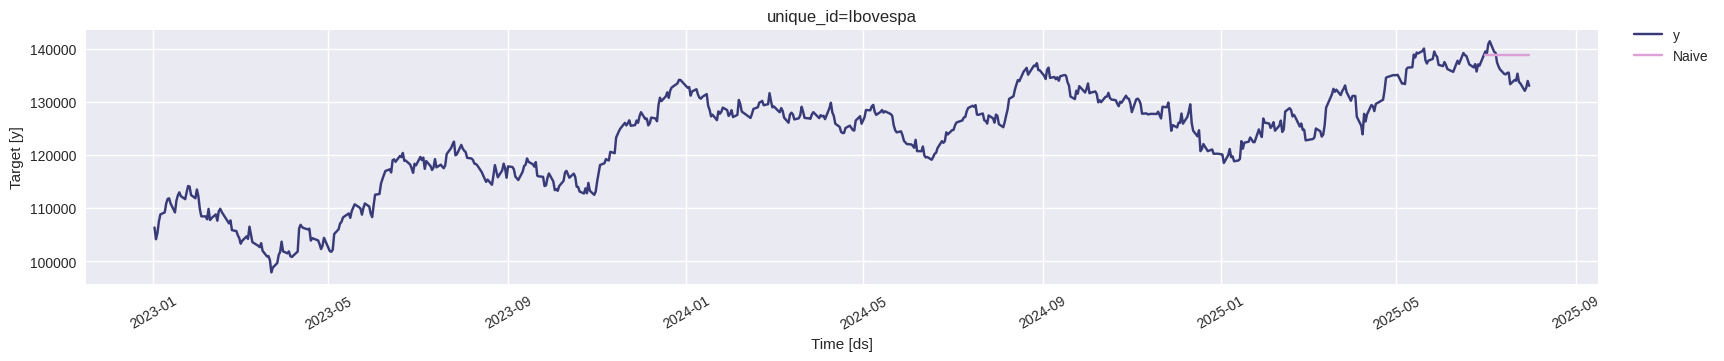

In [176]:
result_baseline = teste.merge(result_baseline, how='left', on=['unique_id', 'ds'])
naive.plot(treino, result_baseline)

In [177]:
result_baseline['y_real'] = (result_baseline['y'].diff()).apply(lambda x: 1 if x > 0 else 0)
result_baseline['y_pred'] = (result_baseline['Naive'].diff()).apply(lambda x: 1 if x > 0 else 0)


In [178]:
print("Acurácia:", accuracy_score(result_baseline['y_real'], result_baseline['y_pred']))
print(classification_report(result_baseline['y_real'], result_baseline['y_pred']))

Acurácia: 0.6521739130434783
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        15
           1       0.00      0.00      0.00         8

    accuracy                           0.65        23
   macro avg       0.33      0.50      0.39        23
weighted avg       0.43      0.65      0.51        23



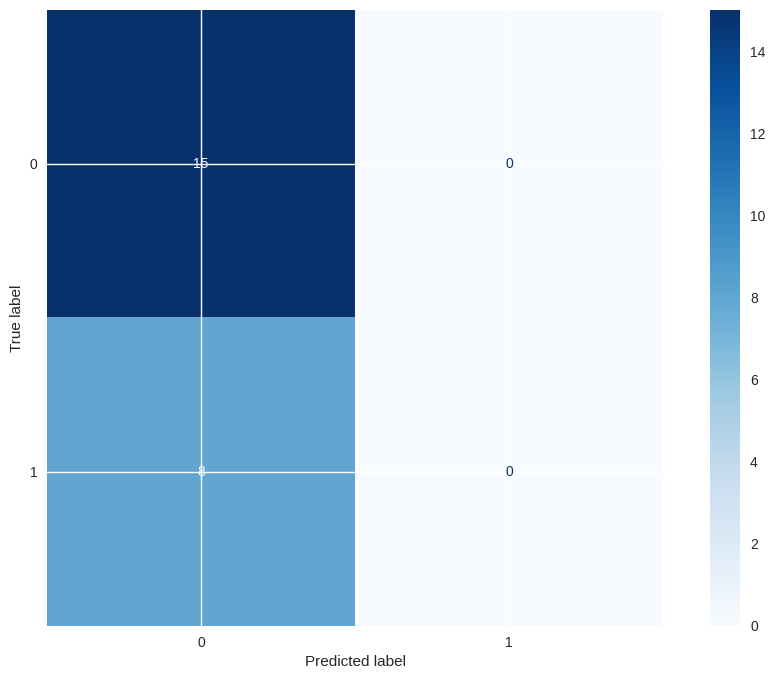

In [179]:
cm_display = ConfusionMatrixDisplay.from_predictions(result_baseline['y_real'], result_baseline['y_pred'],
                                                    cmap='Blues')

###AutoARIMA

In [90]:
model_autoarima = [AutoARIMA(season_length=36)]
auto_arima = StatsForecast(models = model_autoarima, freq ='b', n_jobs=-1)

In [91]:
auto_arima.fit(treino)

StatsForecast(models=[AutoARIMA])

In [92]:
arima_string(auto_arima.fitted_[0,0].model_)

'ARIMA(0,1,0)(1,0,0)[36]                   '

In [165]:
result_aut_arima = auto_arima.predict(h=23)

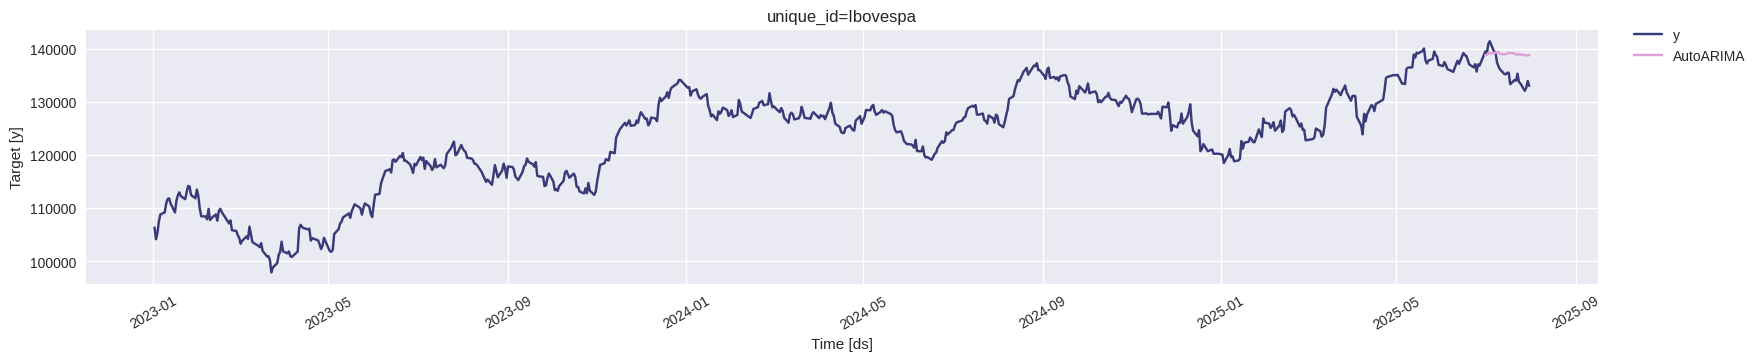

In [166]:
result_aut_arima = teste.merge(result_aut_arima, how='left', on=['unique_id', 'ds'])
naive.plot(treino, result_aut_arima)

In [180]:
result_aut_arima['y_real'] = (result_aut_arima['y'].diff()).apply(lambda x: 1 if x > 0 else 0)
result_aut_arima['y_pred'] = (result_aut_arima['AutoARIMA'].diff()).apply(lambda x: 1 if x > 0 else 0)

In [181]:
print("Acurácia:", accuracy_score(result_baseline['y_real'], result_baseline['y_pred']))
print(classification_report(result_baseline['y_real'], result_baseline['y_pred']))

Acurácia: 0.6521739130434783
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        15
           1       0.00      0.00      0.00         8

    accuracy                           0.65        23
   macro avg       0.33      0.50      0.39        23
weighted avg       0.43      0.65      0.51        23



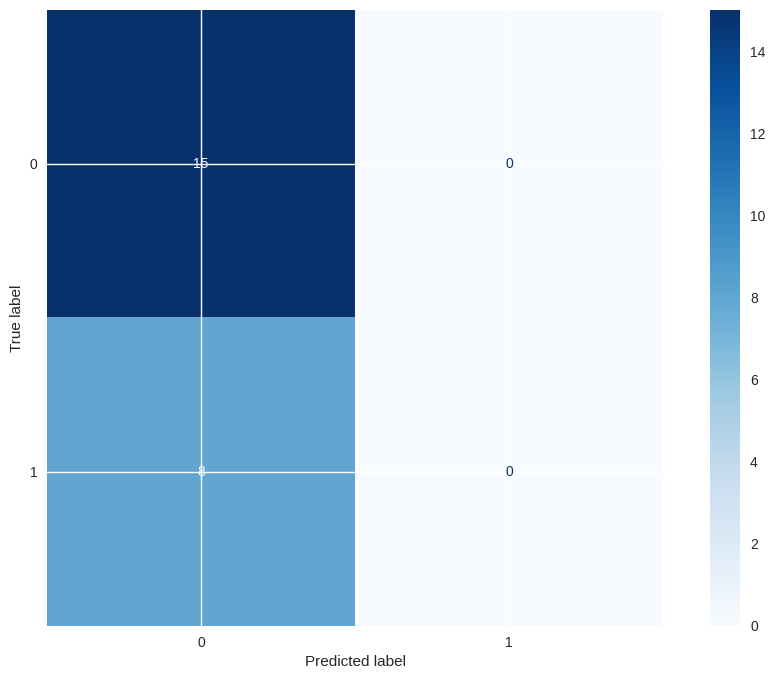

In [182]:
cm_display = ConfusionMatrixDisplay.from_predictions(result_baseline['y_real'], result_baseline['y_pred'],
                                                    cmap='Blues')

### Seasonal Naive

In [785]:
model_snaive = [SeasonalNaive(season_length = 26)]
snaive = StatsForecast(models = model_snaive, freq = 'b', n_jobs = -1)

In [786]:
snaive.fit(treino)
result_snaive = snaive.predict(h=23)

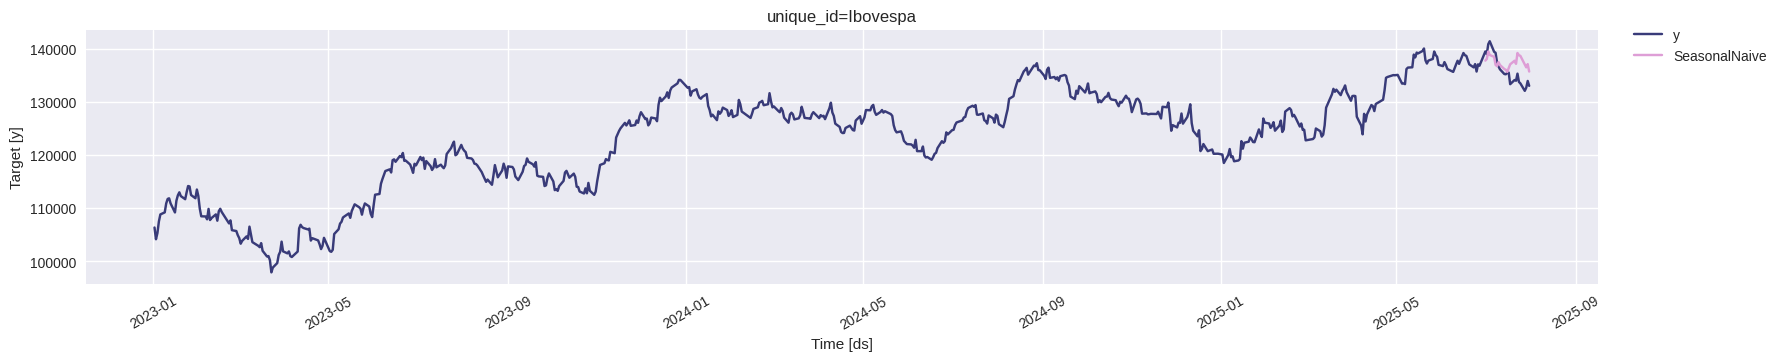

In [787]:
result_snaive = teste.merge(result_snaive, how='left', on=['unique_id', 'ds'])
snaive.plot(treino, result_snaive)

In [788]:
result_snaive['y_real'] = (result_snaive['y'].diff()).apply(lambda x: 1 if x > 0 else 0)
result_snaive['y_pred'] = (result_snaive['SeasonalNaive'].diff()).apply(lambda x: 1 if x > 0 else 0)

Acurácia: 0.74
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        15
           1       0.62      0.62      0.62         8

    accuracy                           0.74        23
   macro avg       0.71      0.71      0.71        23
weighted avg       0.74      0.74      0.74        23



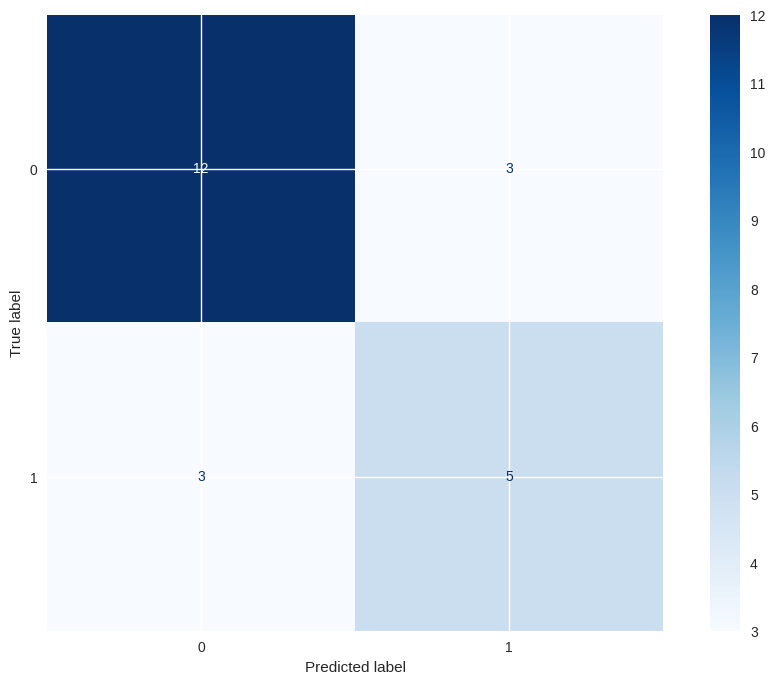

In [789]:
print("Acurácia:", round(accuracy_score(result_snaive['y_real'], result_snaive['y_pred']),2))
print(classification_report(result_snaive['y_real'], result_snaive['y_pred']))
cm_display = ConfusionMatrixDisplay.from_predictions(result_snaive['y_real'], result_snaive['y_pred'],
                                                    cmap='Blues')

### MSTL

In [902]:
model_mstl = [MSTL(season_length=[5, 10, 15, 25, 30, 50], # seasonalities of the time series
trend_forecaster=AutoARIMA(prediction_intervals=ConformalIntervals(n_windows=3, h=23)))]
mstl = StatsForecast(models = model_mstl, freq = 'b', n_jobs = -1)

In [903]:
mstl.fit(treino)
result_mstl = mstl.predict(h=23)

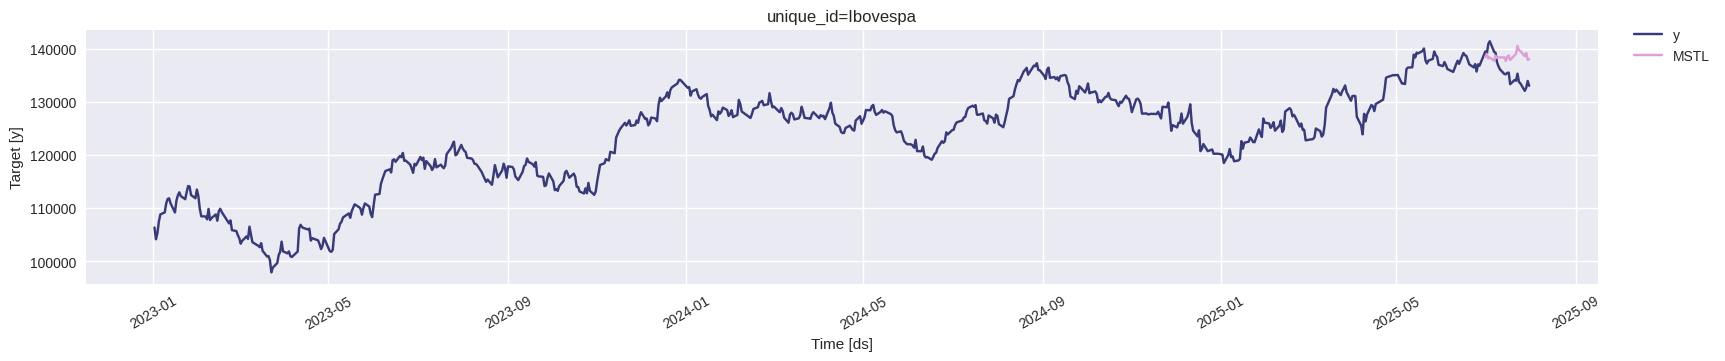

In [904]:
result_mstl = teste.merge(result_mstl, how='left', on=['unique_id', 'ds'])
mstl.plot(treino, result_mstl)

In [905]:
result_mstl['y_real'] = (result_mstl['y'].diff()).apply(lambda x: 1 if x > 0 else 0)
result_mstl['y_pred'] = (result_mstl['MSTL'].diff()).apply(lambda x: 1 if x > 0 else 0)

Acurácia: 0.65
              precision    recall  f1-score   support

           0       0.82      0.60      0.69        15
           1       0.50      0.75      0.60         8

    accuracy                           0.65        23
   macro avg       0.66      0.68      0.65        23
weighted avg       0.71      0.65      0.66        23



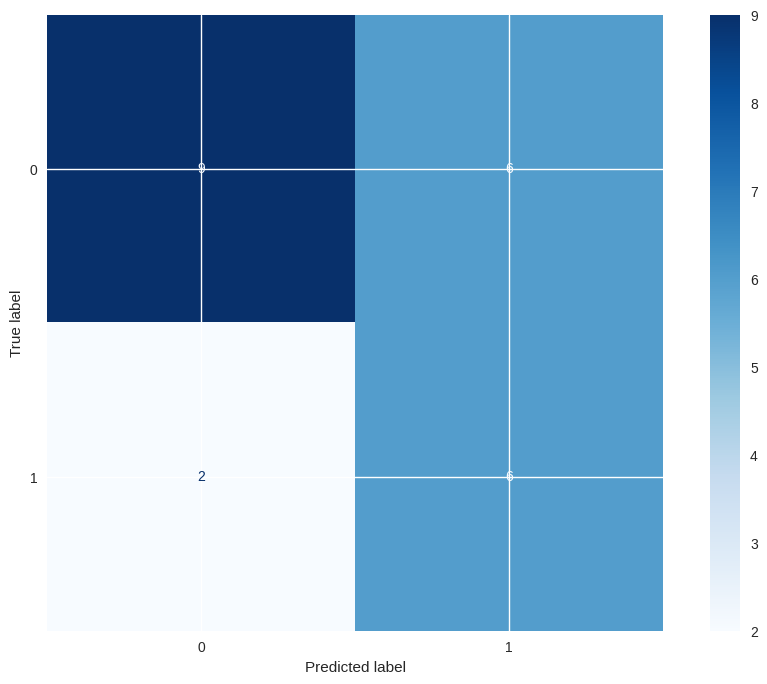

In [906]:
print("Acurácia:", round(accuracy_score(result_mstl['y_real'], result_mstl['y_pred']),2))
print(classification_report(result_mstl['y_real'], result_mstl['y_pred']))
cm_display = ConfusionMatrixDisplay.from_predictions(result_mstl['y_real'], result_mstl['y_pred'],
                                                    cmap='Blues')

### Random Forest Regression

In [98]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import ta  # Biblioteca para indicadores técnicos

In [1027]:

data = pd.DataFrame()
data['Close'] = df['Close']
data['High'] = df['High']
data['Low'] = df['Low']
data['Open'] = df['Open']
data['Volume'] = df['Volume']


In [1028]:
data['Return_1d'] = data['Close'].pct_change()
data['Return_5d'] = data['Close'].pct_change(5)
data['Return_10d'] = data['Close'].pct_change(10)
data['Return_20d'] = data['Close'].pct_change(20)

In [1029]:
data['Volatility_5d'] = data['Return_1d'].rolling(5).std()
data['Volatility_10d'] = data['Return_1d'].rolling(10).std()
data['Volatility_20d'] = data['Return_1d'].rolling(20).std()

In [1030]:
data['SMA_5'] = data['Close'].rolling(5).mean()
data['SMA_10'] = data['Close'].rolling(10).mean()
data['SMA_20'] = data['Close'].rolling(20).mean()
data['SMA_50'] = data['Close'].rolling(50).mean()

In [1031]:
data['EMA_5'] = data['Close'].ewm(span=5).mean()
data['EMA_10'] = data['Close'].ewm(span=10).mean()
data['EMA_20'] = data['Close'].ewm(span=20).mean()

In [1032]:
data['SMA_5_20_ratio'] = data['SMA_5'] / data['SMA_20']
data['EMA_5_20_ratio'] = data['EMA_5'] / data['EMA_20']

In [1033]:
data['RSI_14'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()

In [1034]:
macd = ta.trend.MACD(data['Close'])
data['MACD'] = macd.macd()
data['MACD_Signal'] = macd.macd_signal()
data['MACD_Histogram'] = macd.macd_diff()

In [1035]:
bollinger = ta.volatility.BollingerBands(data['Close'], window=20)
data['BB_Upper'] = bollinger.bollinger_hband()
data['BB_Lower'] = bollinger.bollinger_lband()
data['BB_Middle'] = bollinger.bollinger_mavg()
data['BB_Width'] = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Middle']
data['BB_Position'] = (data['Close'] - data['BB_Lower']) / (data['BB_Upper'] - data['BB_Lower'])

In [1036]:
stoch = ta.momentum.StochasticOscillator(data['High'], data['Low'], data['Close'])
data['Stoch_K'] = stoch.stoch()
data['Stoch_D'] = stoch.stoch_signal()

In [1037]:
data['Williams_R'] = ta.momentum.WilliamsRIndicator(data['High'], data['Low'], data['Close']).williams_r()

In [1038]:
data['Volume_SMA_10'] = data['Volume'].rolling(10).mean()
data['Volume_Ratio'] = data['Volume'] / data['Volume_SMA_10']

In [1039]:
data['OBV'] = ta.volume.OnBalanceVolumeIndicator(data['Close'], data['Volume']).on_balance_volume()

In [1040]:
data['DayOfWeek'] = data.index.dayofweek
data['IsMonday'] = (data['DayOfWeek'] == 0).astype(int)
data['IsFriday'] = (data['DayOfWeek'] == 4).astype(int)

In [1041]:
data['Month'] = data.index.month
data['Quarter'] = data.index.quarter

In [1042]:
for lag in [1, 2, 3, 5, 10]:
  data[f'Close_Lag_{lag}'] = data['Close'].shift(lag)

for lag in [1, 2, 3]:
  data[f'Return_Lag_{lag}'] = data['Return_1d'].shift(lag)

In [1043]:
data['True_Range'] = ta.volatility.AverageTrueRange(data['High'], data['Low'], data['Close']).average_true_range()

In [1044]:
data['CCI'] = ta.trend.CCIIndicator(data['High'], data['Low'], data['Close']).cci()

In [1045]:
data['ROC'] = ta.momentum.ROCIndicator(data['Close']).roc()

In [1046]:
data.head()

,Close,High,Low,Open,Volume,Return_1d,Return_5d,Return_10d,Return_20d,Volatility_5d,...,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,True_Range,CCI,ROC
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,106376.0,109734.0,105981.0,109734.0,8130500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-01-03,104166.0,106684.0,103852.0,106377.0,14466700,-0.020775,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-01-04,105334.0,105627.0,103915.0,104167.0,14451200,0.011213,NaN,NaN,NaN,NaN,...,106376.0,NaN,NaN,NaN,-0.020775,NaN,NaN,0.0,NaN,NaN
2023-01-05,107518.0,107743.0,105333.0,105336.0,15512000,0.020734,NaN,NaN,NaN,NaN,...,104166.0,106376.0,NaN,NaN,0.011213,-0.020775,NaN,0.0,NaN,NaN
2023-01-06,108836.0,109433.0,107642.0,107642.0,12626600,0.012258,NaN,NaN,NaN,NaN,...,105334.0,104166.0,NaN,NaN,0.020734,0.011213,-0.020775,0.0,NaN,NaN


In [1049]:
df_features = data.copy()

In [1050]:
df_clean = df_features.dropna()

In [1051]:
df_clean

,Close,High,Low,Open,Volume,Return_1d,Return_5d,Return_10d,Return_20d,Volatility_5d,...,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,True_Range,CCI,ROC
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-14,102932.0,104153.0,102482.0,103121.0,13133800,-0.001833,-0.012434,-0.019060,-0.048248,0.014753,...,103618.0,105071.0,104228.0,104932.0,-0.004796,-0.013829,-0.013788,1879.251999,-102.410588,-2.777856
2023-03-15,102675.0,103048.0,100692.0,102930.0,15246500,-0.002497,-0.036277,-0.016382,-0.056695,0.005999,...,103121.0,103618.0,106540.0,104385.0,-0.001833,-0.004796,-0.013829,1913.305427,-129.255492,-2.871981
2023-03-16,103435.0,103911.0,102455.0,102683.0,14385800,0.007402,-0.015570,0.001055,-0.039235,0.007587,...,102932.0,103121.0,105071.0,103326.0,-0.002497,-0.001833,-0.004796,1880.640754,-80.290882,-1.426638
2023-03-17,101982.0,103434.0,101664.0,103434.0,17560000,-0.014047,-0.015789,-0.018139,-0.068164,0.007664,...,102675.0,102932.0,103618.0,103866.0,0.007402,-0.002497,-0.001833,1872.809272,-104.867984,-2.302055
2023-03-20,100923.0,102328.0,100679.0,101982.0,0,-0.010384,-0.021315,-0.036074,-0.081725,0.008341,...,103435.0,102675.0,103121.0,104700.0,-0.014047,0.007402,-0.002497,1856.822895,-138.382785,-2.325649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,133524.0,134204.0,133285.0,133820.0,5560900,-0.002122,0.001065,-0.019554,-0.024418,0.008237,...,135368.0,134036.0,133382.0,136187.0,-0.011524,0.009938,-0.000976,1540.065549,-96.012648,-2.878216
2025-07-28,132129.0,133902.0,131550.0,133538.0,6625600,-0.010448,-0.015190,-0.023430,-0.048439,0.008666,...,133808.0,135368.0,134167.0,135299.0,-0.002122,-0.011524,0.009938,1598.060867,-118.126373,-3.374213
2025-07-29,132726.0,133346.0,132130.0,132130.0,6324800,0.004518,-0.009773,-0.018662,-0.048893,0.009315,...,133524.0,133808.0,134036.0,135250.0,-0.010448,-0.002122,-0.011524,1570.842234,-104.677037,-2.541359


In [1052]:
X = df_clean.drop(columns = 'Close')
y = df_clean['Close']

In [1056]:
data_inicio = '2025-07-01'
data_fim = '2025-07-31'
serie_datas = df_clean.index
masc_julho = (serie_datas >= data_inicio) & (serie_datas <= data_fim)

In [987]:
masc_treino = serie_datas < data_inicio

X_train = X[masc_treino]
X_test = X[masc_julho]
y_train = y[masc_treino]
y_test = y[masc_julho]

In [147]:
feature_names = [col for col in df_clean.columns if col != 'Close']
print(feature_names)

['High', 'Low', 'Open', 'Volume', 'Return_1d', 'Return_5d', 'Return_10d', 'Return_20d', 'Volatility_5d', 'Volatility_10d', 'Volatility_20d', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_5', 'EMA_10', 'EMA_20', 'SMA_5_20_ratio', 'EMA_5_20_ratio', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Upper', 'BB_Lower', 'BB_Middle', 'BB_Width', 'BB_Position', 'Stoch_K', 'Stoch_D', 'Williams_R', 'Volume_SMA_10', 'Volume_Ratio', 'OBV', 'DayOfWeek', 'IsMonday', 'IsFriday', 'Month', 'Quarter', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'True_Range', 'CCI', 'ROC']


In [127]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.3],
    'bootstrap': [True, False]
}
cv_splits=5
tscv = TimeSeriesSplit(n_splits=cv_splits)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

In [128]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [10, 15, 20, None],
                         'max_features': ['sqrt', 'log2', 0.3],
                         'min_samples_leaf': [2, 4, 6],
                         'min_samples_split': [5, 10, 15],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=1)

In [129]:
best_model_rf = grid_search.best_estimator_

In [130]:
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor score: {-grid_search.best_score_:.2f}")

Melhores parâmetros: {'bootstrap': False, 'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}
Melhor score: 3832429.49


In [ ]:
# ================================================================================
# 4. OTIMIZAÇÃO DE HIPERPARÂMETROS
# ================================================================================

# Param grid otimizado para regressão de séries temporais financeiras

def optimize_random_forest(X_train, y_train, param_grid, cv_splits=5):
    """
    Otimiza hiperparâmetros do RandomForestRegressor
    """
    print(f"\n🎯 Otimizando hiperparâmetros...")
    print(f"⏱️  Isso pode demorar alguns minutos...")

    # TimeSeriesSplit para validação cruzada temporal
    tscv = TimeSeriesSplit(n_splits=cv_splits)

    # Modelo base
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)

    # Grid Search
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    # Fit
    grid_search.fit(X_train, y_train)

    print(f"✅ Otimização concluída!")
    print(f"🏆 Melhores parâmetros: {grid_search.best_params_}")
    print(f"📊 Melhor score: {-grid_search.best_score_:.2f}")

    return grid_search.best_estimator_

# Executando otimização
best_rf = optimize_random_forest(X_train, y_train, param_grid)


🎯 Otimizando hiperparâmetros...
⏱️  Isso pode demorar alguns minutos...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
✅ Otimização concluída!
🏆 Melhores parâmetros: {'bootstrap': False, 'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}
📊 Melhor score: 3832429.49


In [131]:
best_model_rf.fit(X_train, y_train)

y_train_pred = best_model_rf.predict(X_train)
y_test_pred = best_model_rf.predict(X_test)

In [133]:
def evaluate_model(y_true, y_pred, dataset_name=""):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\nMétricas - {dataset_name}:")
    print(f"MSE: {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE: {mae:,.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# Avaliando o modelo
train_metrics = evaluate_model(y_train, y_train_pred, "Treino")
test_metrics = evaluate_model(y_test, y_test_pred, "Teste")




Métricas - Treino:
MSE: 80,751.97
RMSE: 284.17
MAE: 197.45
R²: 0.9990
MAPE: 0.16%

Métricas - Teste:
MSE: 733,240.87
RMSE: 856.29
MAE: 617.64
R²: 0.8992
MAPE: 0.45%


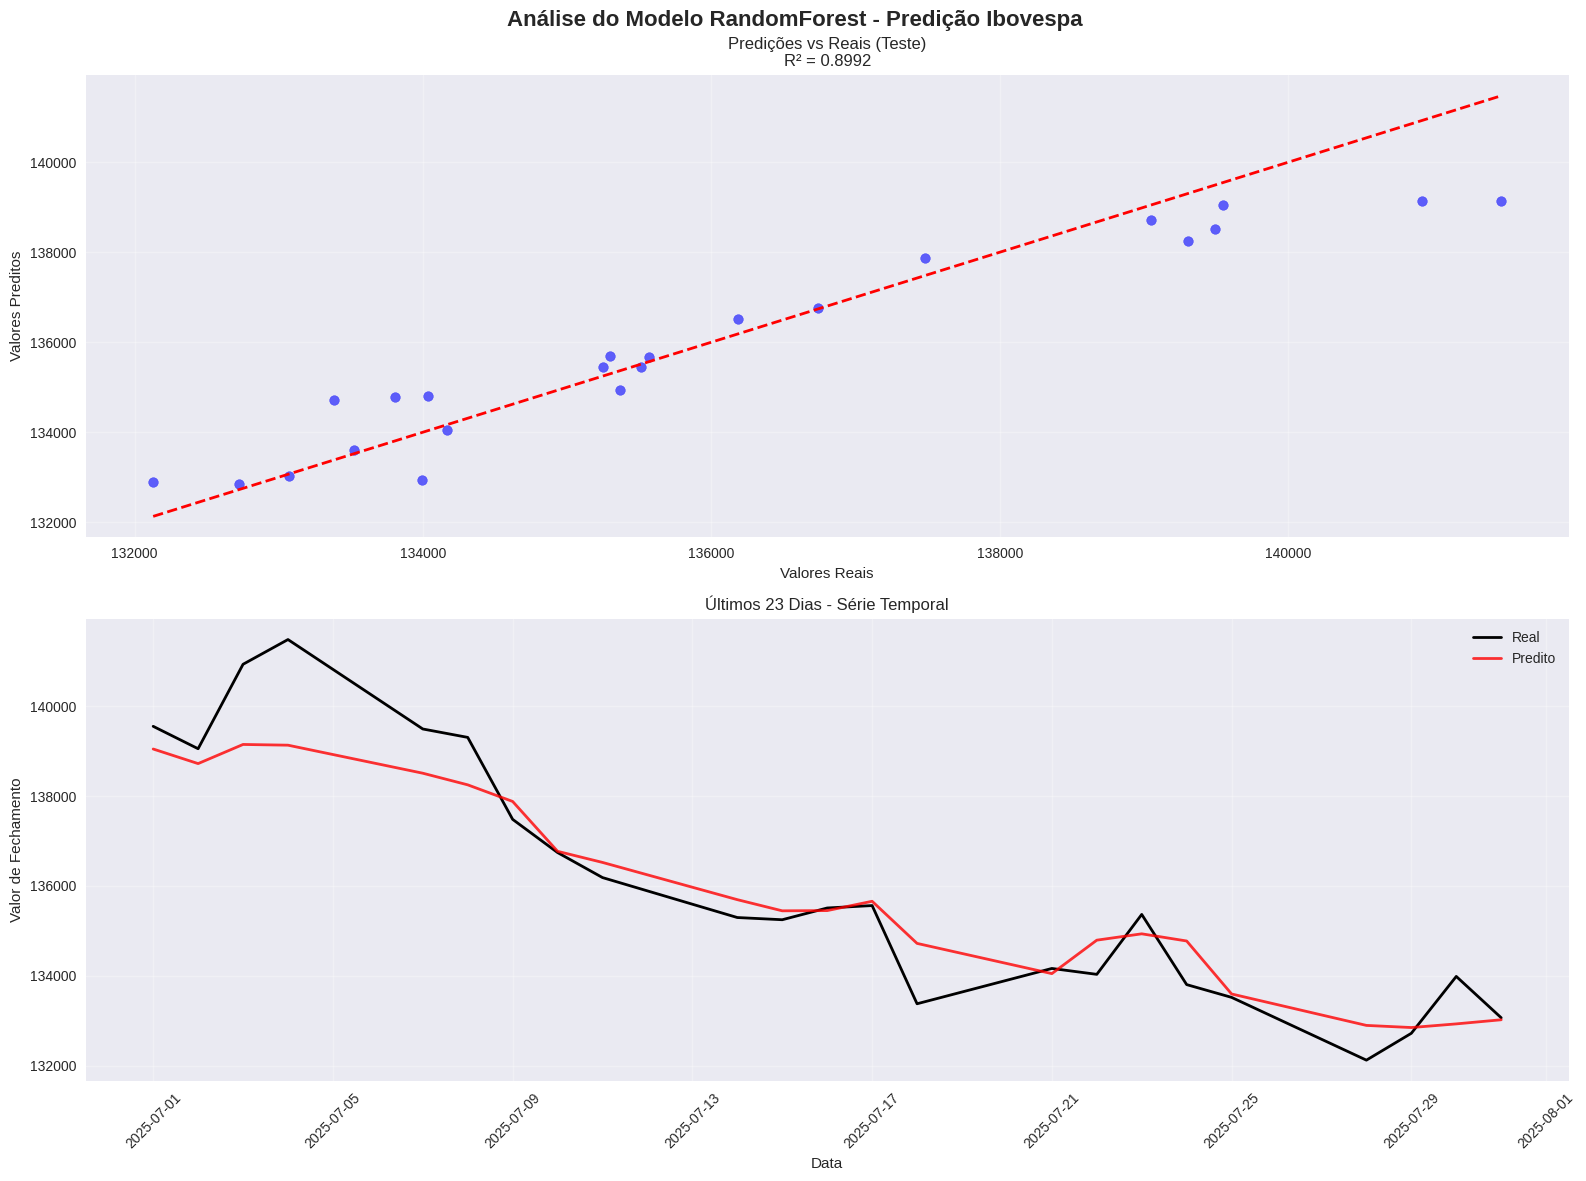

In [134]:

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Análise do Modelo RandomForest - Predição Ibovespa', fontsize=16, fontweight='bold')

# 1. Valores Reais vs Preditos (Teste)
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reais')
axes[0].set_ylabel('Valores Preditos')
axes[0].set_title(f'Predições vs Reais (Teste)\nR² = {test_metrics["R2"]:.4f}')
axes[0].grid(True, alpha=0.3)

# 2. Série temporal - Últimos 100 dias
last_100_days = min(100, len(y_test))
test_dates = y_test.index[-last_100_days:]
axes[1].plot(test_dates, y_test.iloc[-last_100_days:], label='Real', linewidth=2, color='black')
axes[1].plot(test_dates, y_test_pred[-last_100_days:], label='Predito', linewidth=2, color='red', alpha=0.8)
axes[1].set_title(f'Últimos {last_100_days} Dias - Série Temporal')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Valor de Fechamento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [148]:
def get_top_features_pandas(model, feature_names, top_n=10):
    """
    Retorna as top N features mais importantes usando pandas
    """
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })

    # Ordenando por importância (decrescente)
    top_features = feature_importance.sort_values('importance', ascending=False).head(top_n)

    return top_features

In [149]:
top_features_df = get_top_features_pandas(best_model_rf, feature_names, 10)
print(top_features_df)

        feature  importance
0          High    0.256955
1           Low    0.216068
15        EMA_5    0.146012
11        SMA_5    0.104650
2          Open    0.060167
40  Close_Lag_1    0.046527
41  Close_Lag_2    0.033982
16       EMA_10    0.032269
13       SMA_20    0.024913
12       SMA_10    0.021413


In [150]:
def create_consolidated_results_df(y_train, y_train_pred, y_test, y_test_pred):
    """
    Cria DataFrame consolidado com datas, valores reais e preditos
    """
    print("\n📋 Criando DataFrame consolidado...")

    # DataFrame para dados de treino
    train_df = pd.DataFrame({
        'Data': y_train.index,
        'Valor_Real': y_train.values,
        'Valor_Predito': y_train_pred,
        'Conjunto': 'Treino'
    })

    # DataFrame para dados de teste
    test_df = pd.DataFrame({
        'Data': y_test.index,
        'Valor_Real': y_test.values,
        'Valor_Predito': y_test_pred,
        'Conjunto': 'Teste'
    })

    # Consolidando
    df_consolidated = pd.concat([train_df, test_df], ignore_index=True)
    df_consolidated = df_consolidated.sort_values('Data').reset_index(drop=True)

    return df_consolidated

df_results = create_consolidated_results_df(y_train, y_train_pred, y_test, y_test_pred)


📋 Criando DataFrame consolidado...


In [151]:
df_results['y_real'] = (df_results['Valor_Real'].pct_change()).apply(lambda x: 1 if x >= 0.005 else 0)
df_results['y_pred'] = (df_results['Valor_Predito'].pct_change()).apply(lambda x: 1 if x >= 0.005 else 0)
df_results.head()

,Data,Valor_Real,Valor_Predito,Conjunto,y_real,y_pred
0,2023-03-14,102932.0,103150.156865,Treino,0,0
1,2023-03-15,102675.0,102600.129890,Treino,0,0
2,2023-03-16,103435.0,103195.841495,Treino,1,1
3,2023-03-17,101982.0,102126.000536,Treino,0,0
4,2023-03-20,100923.0,100257.480476,Treino,0,0


In [152]:
df_jul = df_results.loc[df_results['Data'] >= '2025-07-01']
df_jul.head(21)

,Data,Valor_Real,Valor_Predito,Conjunto,y_real,y_pred
572,2025-07-01,139549.0,139044.813336,Teste,0,0
573,2025-07-02,139051.0,138720.563640,Teste,0,0
574,2025-07-03,140928.0,139145.942971,Teste,1,0
575,2025-07-04,141478.0,139129.876027,Teste,0,0
576,2025-07-07,139490.0,138506.832099,Teste,0,0
577,2025-07-08,139303.0,138248.303217,Teste,0,0
578,2025-07-09,137481.0,137878.873627,Teste,0,0
579,2025-07-10,136743.0,136770.627106,Teste,0,0
580,2025-07-11,136187.0,136523.723494,Teste,0,0
581,2025-07-14,135299.0,135696.170998,Teste,0,0


In [153]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

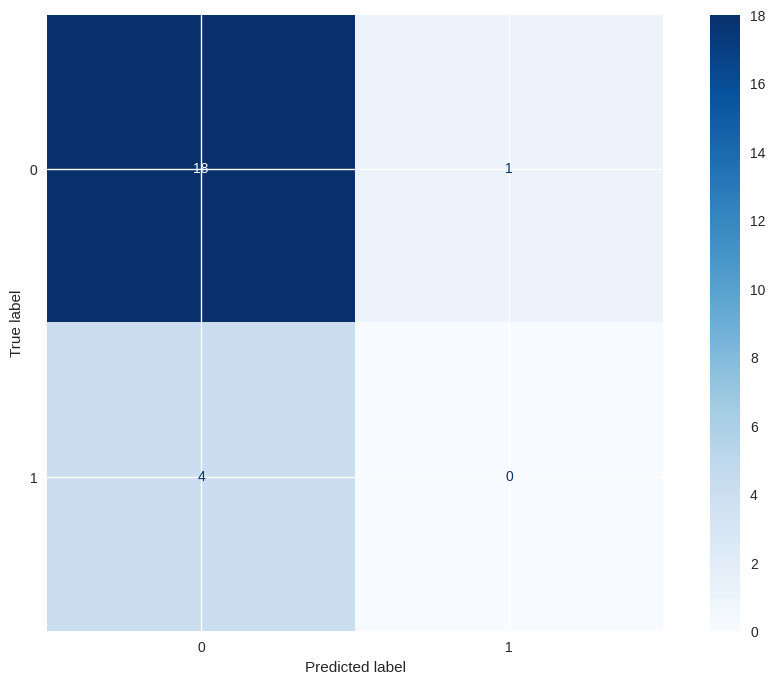

In [1081]:
cm_display = ConfusionMatrixDisplay.from_predictions(df_jul['y_real'], df_jul['y_pred'],
                                                    cmap='Blues')

In [155]:
print("Acurácia:", accuracy_score(df_jul['y_real'], df_jul['y_pred']))
print(classification_report(df_jul['y_real'], df_jul['y_pred']))

Acurácia: 0.782608695652174
              precision    recall  f1-score   support

           0       0.82      0.95      0.88        19
           1       0.00      0.00      0.00         4

    accuracy                           0.78        23
   macro avg       0.41      0.47      0.44        23
weighted avg       0.68      0.78      0.73        23



In [1057]:
X_treino = X[masc_treino]
X_teste = X[masc_julho]
y_treino = y[masc_treino]
y_teste = y[masc_julho]

In [1058]:
X_treino

,High,Low,Open,Volume,Return_1d,Return_5d,Return_10d,Return_20d,Volatility_5d,Volatility_10d,...,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,True_Range,CCI,ROC
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-14,104153.0,102482.0,103121.0,13133800,-0.001833,-0.012434,-0.019060,-0.048248,0.014753,0.011091,...,103618.0,105071.0,104228.0,104932.0,-0.004796,-0.013829,-0.013788,1879.251999,-102.410588,-2.777856
2023-03-15,103048.0,100692.0,102930.0,15246500,-0.002497,-0.036277,-0.016382,-0.056695,0.005999,0.011033,...,103121.0,103618.0,106540.0,104385.0,-0.001833,-0.004796,-0.013829,1913.305427,-129.255492,-2.871981
2023-03-16,103911.0,102455.0,102683.0,14385800,0.007402,-0.015570,0.001055,-0.039235,0.007587,0.010917,...,102932.0,103121.0,105071.0,103326.0,-0.002497,-0.001833,-0.004796,1880.640754,-80.290882,-1.426638
2023-03-17,103434.0,101664.0,103434.0,17560000,-0.014047,-0.015789,-0.018139,-0.068164,0.007664,0.011603,...,102675.0,102932.0,103618.0,103866.0,0.007402,-0.002497,-0.001833,1872.809272,-104.867984,-2.302055
2023-03-20,102328.0,100679.0,101982.0,0,-0.010384,-0.021315,-0.036074,-0.081725,0.008341,0.011333,...,103435.0,102675.0,103121.0,104700.0,-0.014047,0.007402,-0.002497,1856.822895,-138.382785,-2.325649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-24,138156.0,136254.0,136552.0,8083700,0.004496,-0.015016,0.010803,-0.007029,0.005807,0.007357,...,137116.0,138717.0,139256.0,135699.0,-0.004121,-0.011541,-0.000886,1676.035208,-23.437214,0.681905
2025-06-25,137163.0,135565.0,137163.0,7705700,-0.010192,-0.022133,-0.004903,-0.027046,0.006635,0.007968,...,136551.0,137116.0,138840.0,136436.0,0.004496,-0.004121,-0.011541,1670.604121,-98.614083,-0.246139
2025-06-26,137353.0,135756.0,135767.0,8023300,0.009921,-0.011556,-0.000102,-0.012773,0.009308,0.008474,...,137165.0,136551.0,138717.0,137128.0,-0.010192,0.004496,-0.004121,1665.346684,-44.678507,1.042749


## Modelos de Classificação

### Regressão Logística

In [908]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [991]:
data["Close"] = df["Close"]

delta = df['Close'].diff()
data["Delta"] = delta.shift(1)

threshold = 0.005  # desconsiderando variações menores que 0.5%
data['Target'] = np.where(
    delta > threshold, 1, np.where(delta < -threshold, 0, np.nan)
)

In [992]:
df_model_class = dataset.dropna().copy()

In [993]:
train = df_model_class.iloc[:-23]
test = df_model_class.iloc[-23:]

predictors = list(train.columns)
predictors.remove('Target')

X_train, X_test = train[predictors], test[predictors]
y_train, y_test = train['Target'], test['Target']

In [994]:
y_train

,Target
Date,
2023-01-04,1.0
2023-01-05,1.0
2023-01-06,1.0
2023-01-09,1.0
2023-01-10,1.0
...,...
2025-06-24,1.0
2025-06-25,0.0
2025-06-26,1.0


In [995]:
pipe_lr = Pipeline(
    [('scaler', StandardScaler()), ('clf', LogisticRegression(solver='liblinear'))]
)

param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=tscv)
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        LogisticRegression(solver='liblinear'))]),
             param_grid={'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'clf__penalty': ['l1', 'l2'],
                         'clf__solver': ['liblinear']})

In [996]:
print("Regressão Logística:")
print("Melhores parâmetros:", grid_lr.best_params_)
print("Acurácia:", accuracy_score(y_test, grid_lr.predict(X_test)))
print(classification_report(y_test, grid_lr.predict(X_test)))

Regressão Logística:
Melhores parâmetros: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Acurácia: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        14
         1.0       1.00      1.00      1.00         9

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [1073]:
pipe_xgb = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier()),
    ]
)

param_grid_xgb = {
    'clf__n_estimators': [100, 200, 300, 400],
    'clf__max_depth': [3, 7, 10, 15],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__gamma': [0, 0.1, 0.5, 1.0],
    'clf__reg_alpha': [0, 0.1, 1],
    'clf__reg_lambda': [0.1, 1, 10],
}

grid_xgb = RandomizedSearchCV(pipe_xgb, param_grid_xgb, cv=tscv)
grid_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metr...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   param_distributions={'clf__colsample_bytree': [0.6, 0.8,
                                                                  1.0],
                                        'clf__gamma': [0, 0.1, 0.5, 1.0],
                                        'clf__learning_rate': [0.01, 0.05, 0.1,
                                                               0.3],
                                        'clf__max_depth': [3, 7, 10, 15],
                                        'clf__n_estimators': [100, 200, 300,
                                                              400],
                                        'clf__reg_alpha': [0, 0.1, 1],
                                        'clf__reg_lambda': [0.1, 1, 10],
                                        'clf__subsample': [0.6, 0.8, 1.0]})

In [1074]:
print("\nXGBoost:")
print("Melhores parâmetros:", grid_xgb.best_params_)
print("Acurácia:", accuracy_score(y_test, grid_xgb.predict(X_test)))
print(classification_report(y_test, grid_xgb.predict(X_test)))


XGBoost:
Melhores parâmetros: {'clf__subsample': 1.0, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0, 'clf__n_estimators': 200, 'clf__max_depth': 15, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}
Acurácia: 0.8260869565217391
              precision    recall  f1-score   support

         0.0       1.00      0.71      0.83        14
         1.0       0.69      1.00      0.82         9

    accuracy                           0.83        23
   macro avg       0.85      0.86      0.83        23
weighted avg       0.88      0.83      0.83        23



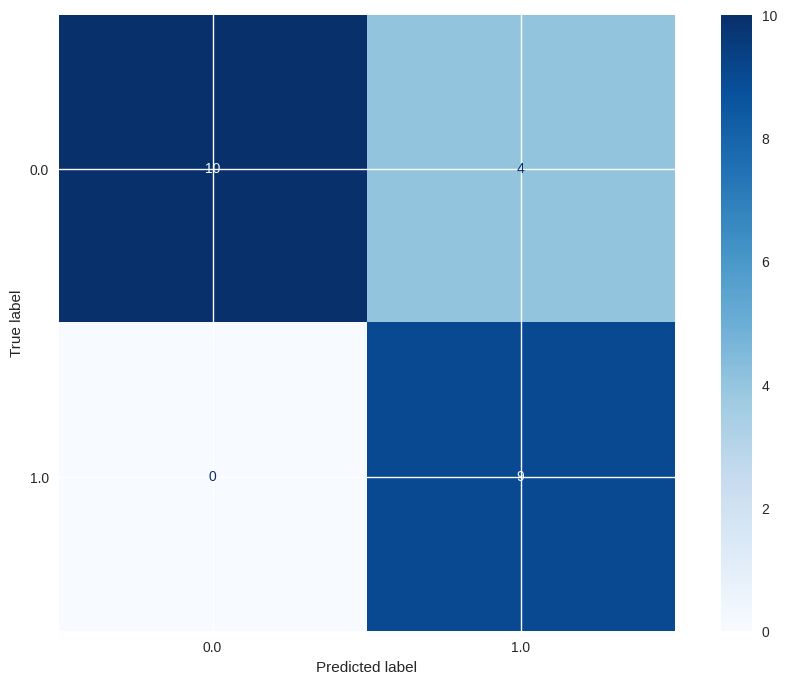

In [1075]:
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, grid_xgb.predict(X_test),
                                                    cmap='Blues')